In [347]:
import numpy as np
from sympy import symbols, simplify, pprint, diff
from scipy.interpolate import lagrange
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
%matplotlib inline

In [348]:
class ConstraintVars:

    def __init__(self, a_M, a_r):
    
    # initialise them as in Thomas's paper with R0=M
    # arXiv:1403.5484
        self.r = a_r
        self.MBH = a_M
        self.psi = np.sqrt(1.0 + self.MBH/self.r)
        self.hrr = 1.0 # this is bar{gamma}_ij = psi^{-4} gamma_ij, flat metric 
        self.htt = self.r * self.r
        self.hpp = self.r * self.r #sintheta = 1
        self.grr = self.psi**4.0 * self.hrr
        self.gtt = self.psi**4.0 * self.htt
        self.gpp = self.psi**4.0 * self.hpp
        self.Lap_psi_over_psi5 = - 0.25 * self.MBH * self.MBH * (self.MBH + self.r)**(-4.0)
        
        # Scalar field
        Rbubble = 5.0
        Abubble = 0.1 #0.5 * np.sqrt(2.0)
        phi = Abubble * (1.0 - np.tanh(self.r - Rbubble))
        dphidr = Abubble / np.cosh(self.r - Rbubble) / np.cosh(self.r - Rbubble)
        
        #phi = Abubble * np.exp(- self.r * self.r / Rbubble / Rbubble)
        #dphidr = (- 2.0 * self.r * Abubble * np.exp(- self.r * self.r / Rbubble / Rbubble)
        #          / Rbubble / Rbubble)
        
        a_Pi = 0.0
        scalar_mass = 1.0
        self.rho = (0.5 * scalar_mass * scalar_mass * phi * phi 
                    + 0.5 / (self.psi**4.0) * dphidr * dphidr
                    + 0.5 * a_Pi * a_Pi)
        self.SiU = 0.0

        # These things update
        self.K0 = -(self.MBH / (self.r + self.MBH) / (self.r + self.MBH))
        r2 = self.r * self.r
        self.Wr0 = -(0.5 * self.MBH / self.r + self.MBH * self.MBH / 3.0 / r2)
        self.dWrdr0 = (0.5 * self.MBH / r2 + 2.0 / 3.0 * self.MBH * self.MBH / r2 / self.r)
        self.Q0 = self.dWrdr0 + 2.0 * self.Wr0 / self.r
        self.K = self.K0
        self.Wr = self.Wr0
        self.dWrdr = self.dWrdr0
        self.Q = self.Q0
        self.update_Aij_vars()
        self.AijAij0 = self.AijAij
        self.Arr0 = self.Arr
        self.Att0 = self.Att
        self.App0 = self.App
        
    def update_Aij_vars(self) :  
        
        r2 = self.r * self.r
        
        # These are \bar{A}_ij = psi^{2} A_ij (A^ij = psi^{-10} \bar{A}^ij)        
        self.Arr = 4.0/3.0 * (self.dWrdr - self.Wr / self.r)
        self.Att = 2.0/3.0 * (- r2 * self.dWrdr + self.r * self.Wr)
        self.App = 2.0/3.0 * (- r2 * self.dWrdr + self.r * self.Wr)
        
        self.AijAij = (self.psi)**(-12.0) * (self.Arr * self.Arr / self.hrr / self.hrr 
                                      + self.Att * self.Att / self.htt / self.htt
                                      + self.App * self.App / self.hpp / self.hpp)

In [349]:
# Functions for solving constraints

def dydr_for_Wr(r, y, dKdr, psi) :
    """Returns the gradient dy/dr for the Mom Constraint"""
    
    Wr = y[0] 
    Qr = y[1] # Qr = dWdr + 2W/r 
    
    dydr = np.zeros_like(y)
        
    # This is dWrdr = Q - 2W/r 
    dydr[0] = Qr - 2 * Wr / r
    # This is dQdr, where Q = dWdr + 2W/r 
    SiU = 0.0
    dydr[1] = 6.0 * np.pi * psi**10.0 * SiU + 0.5 * psi**6.0 * dKdr
    
    return dydr

def integrate_using_midpoint(a_r, a_dydr, y0, a_dKdr, a_psi) :
    
    y_solution = np.zeros([2,np.size(a_r)])
    
    a_dr = a_r[1] - a_r[0] # assume fixed
    
    for ir, r_here in enumerate(a_r) :
        if ir == 0 :
            y_solution[:,ir] = y0
            old_r = r_here
        else :
            dydr_at_r = a_dydr(old_r, y_solution[:,ir-1], a_dKdr[ir-1], a_psi[ir-1])
                
            y_r_plus_half = (y_solution[:,ir-1] + 0.5 *
                                          dydr_at_r * a_dr)
                
            r_plus_half = old_r + 0.5*a_dr
            
            dKdr_r_plus_half = 0.5 * (a_dKdr[ir-1] + a_dKdr[ir])
            psi_r_plus_half = 0.5 * (a_psi[ir-1] + a_psi[ir])
                
            dydr_at_r_plus_half = a_dydr(r_plus_half, y_r_plus_half, 
                                       dKdr_r_plus_half, psi_r_plus_half)
                
            y_solution[:,ir] = (y_solution[:,ir-1] + 
                                          dydr_at_r_plus_half * a_dr) 
            old_r = r_here
    
    Wr = y_solution[0, :]
    Qr = y_solution[1, :]
    dWrdr = Qr - 2.0/a_r * Wr
    
    return Wr, dWrdr, Qr

def get_Ham(a_vars) :
    """Returns the value of the Ham constraint"""
    
    Ham = a_vars.K * a_vars.K - 1.5 * a_vars.AijAij - 24.0 * np.pi * a_vars.rho - 12.0 * a_vars.Lap_psi_over_psi5
    
    return Ham

def get_Mom(a_vars) :
    """Returns the value of the Mom constraint"""

    csQ = CubicSpline(a_vars.r, a_vars.Q)
    dQdr = csQ(a_vars.r, 1)
    
    csK = CubicSpline(a_vars.r, a_vars.K)
    dKdr = csK(a_vars.r, 1)
    
    Mom = dQdr - 6.0 * np.pi * a_vars.psi**10.0 * a_vars.SiU - 0.5 * a_vars.psi**6.0 * dKdr
    
    return Mom

def get_deltaK(a_vars) :
    """Returns the value of K from the Ham constraint"""
    
    Ksquared = 12.0 * a_vars.Lap_psi_over_psi5 + 1.5 * a_vars.AijAij + 24.0 * np.pi * a_vars.rho
    
    assert (Ksquared.all() > 0), "K squared negative"
    
    minusK = - np.sqrt(np.abs(Ksquared))
    
    deltaK = minusK - a_vars.K0
    
    return deltaK

def solve_for_Wr(a_vars, ddeltaKdr) :
    
    q0 = 0.0
    r0 = a_vars.r[0]
    w0 = q0 * r0 / 3.0

    #csrho = CubicSpline(a_vars.r, a_vars.rho)
    #d2rhodr2 = csrho(a_vars.r, 2)
    
    #rho2 = d2rhodr2[0] # second deriv at r0
    #w_const = -12.0/7.0 * np.pi * a_vars.MBH**4.0 * rho2
    #wl = -384.0/49.0 * np.pi * a_vars.MBH**3.0 * rho2
    #w1 = -128.0/49.0 * np.pi * a_vars.MBH**3.0 * rho2
    #w0 = w_const + wl * r0 * np.log(r0) + w1 * r0
        
    # test new value
    y0 = np.array([w0, q0])
    Wr_test, dWrdr_test, Q_test = integrate_using_midpoint(a_vars.r, dydr_for_Wr, y0, ddeltaKdr, a_vars.psi)
    
    #print(q0, Q_test[-1])
    
    for i in np.arange(3) :
        # Correct the q0 values for the linear term
        q0 += - Q_test[-1]
        w0 = q0 * r0 / 3.0 
        y0 = np.array([w0, q0])
        Wr_test, dWrdr_test, Q_test = integrate_using_midpoint(a_vars.r, dydr_for_Wr, y0, ddeltaKdr, a_vars.psi)
        #print(q0, Q_test[-1])
        
        
    # Free to add C/r^2 to W
    C = 0
    Wr_test = Wr_test + C / a_vars.r / a_vars.r
    dWrdr_test = dWrdr_test - 2.0 * C / a_vars.r / a_vars.r / a_vars.r
    
    return Wr_test, dWrdr_test, Q_test

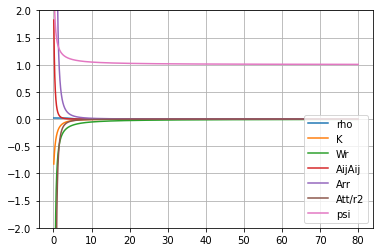

In [350]:
# Choose params
Rmax_approx = 80.0 # set this roughly, fixed below
dr = 0.01
Rmin = 0.1
M_BH = 1.0

# Work out r vector
num_points = int((Rmax_approx - Rmin)/dr) + 1
Rmax = Rmin + (num_points - 1) * dr
r_vec = np.linspace(Rmin, Rmax, num_points) 

my_vars = ConstraintVars(M_BH, r_vec)

plt.plot(my_vars.r, my_vars.rho, label='rho')
plt.plot(my_vars.r, my_vars.K, label='K')
plt.plot(my_vars.r, my_vars.Wr, label='Wr')
plt.plot(my_vars.r, my_vars.AijAij, label='AijAij')
plt.plot(my_vars.r, my_vars.Arr, label='Arr')
plt.plot(my_vars.r, my_vars.Att / my_vars.r / my_vars.r, label='Att/r2')
plt.plot(my_vars.r, my_vars.psi, label='psi')
plt.legend(loc=4)
plt.ylim(-2,2)
plt.grid();

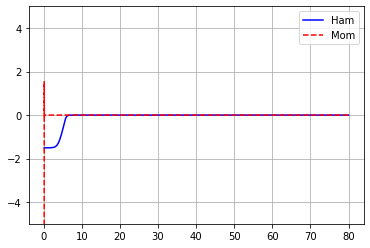

In [351]:
Ham = get_Ham(my_vars)
Mom = get_Mom(my_vars)

plt.plot(my_vars.r, Ham, 'b-', label='Ham')
plt.plot(my_vars.r, Mom, 'r--', label='Mom')
plt.legend()
plt.ylim(-5,5)
plt.grid();

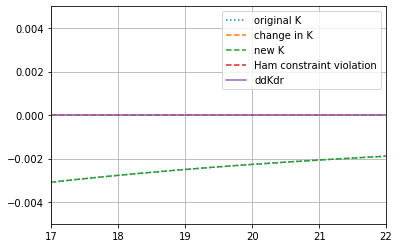

In [352]:
# Check the K part works
plt.plot(my_vars.r, my_vars.K0, ':', label='original K')
deltaK = get_deltaK(my_vars)
my_vars.K = my_vars.K0 + deltaK
Ham = get_Ham(my_vars)
plt.plot(my_vars.r, deltaK, '--', label='change in K')
plt.plot(my_vars.r, my_vars.K, '--', label='new K')
plt.plot(my_vars.r, Ham, '--', label='Ham constraint violation')

# Derivative of the change
cs = CubicSpline(my_vars.r, deltaK)
ddeltaKdr = cs(my_vars.r, 1)
plt.plot(my_vars.r, ddeltaKdr,label='ddKdr')

plt.legend()
plt.xlim(17.0,22)
plt.ylim(-0.005,0.005)
plt.grid();

-1.3679609697321283e-15 0.7898955940889713


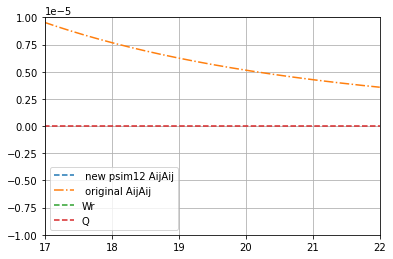

In [353]:
Wr, dWrdr, Q = solve_for_Wr(my_vars, ddeltaKdr)
# Should be small
print(Q[-1], Wr[0])

my_vars.Q = my_vars.Q0 + Q
my_vars.Wr = my_vars.Wr0 + Wr
my_vars.dWrdr = my_vars.dWrdr0 + dWrdr
my_vars.update_Aij_vars() # Need full Aijs for the Ham constraint
plt.plot(my_vars.r, 12.0 * my_vars.Lap_psi_over_psi5 + 1.5 * my_vars.AijAij, '--', label=' new psim12 AijAij')
plt.plot(my_vars.r, 12.0 * my_vars.Lap_psi_over_psi5 + 1.5 * my_vars.AijAij0, '-.', label=' original AijAij')
plt.plot(my_vars.r, Wr, '--', label='Wr')
plt.plot(my_vars.r, Q, '--', label='Q')
Ham = get_Ham(my_vars)
Mom = get_Mom(my_vars)

#plt.plot(my_vars.r, Ham, 'b-', label='Ham')
#plt.plot(my_vars.r, Mom, 'r--', label='Mom')

plt.legend()
plt.xlim(17.0,22)
#plt.ylim(-0.1,0.1)
plt.ylim(-0.00001,0.00001)
plt.grid();

In [354]:
# iterate
deltaK = get_deltaK(my_vars) # Because Aij has changed
my_vars.K = my_vars.K0 + deltaK 
cs = CubicSpline(my_vars.r, deltaK)
ddeltaKdr = cs(my_vars.r, 1) # first derivative of dK

max_iter = 100
for i in np.arange(max_iter) :
    frac = (float(i + 0.5 * max_iter) / max_iter)
    frac = min(frac, 1.0)
    # Solve for correction to Wr, sourced by change in dKdr
    Wr, dWrdr, Q = solve_for_Wr(my_vars, ddeltaKdr)
    my_vars.Q = my_vars.Q0 + frac * Q
    my_vars.Wr = my_vars.Wr0 + frac * Wr
    my_vars.dWrdr = my_vars.dWrdr0 + frac * dWrdr
    my_vars.update_Aij_vars() # Need full Aijs for the Ham constraint
    deltaK = get_deltaK(my_vars) # Because Aij has changed
    my_vars.K = my_vars.K0 + deltaK
    cs = CubicSpline(my_vars.r, deltaK)
    ddeltaKdr = cs(my_vars.r, 1) # first derivative of dK

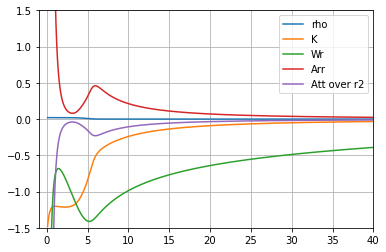

In [355]:
# Check the results
plt.plot(my_vars.r, my_vars.rho, label='rho')
plt.plot(my_vars.r, my_vars.K, label='K')
plt.plot(my_vars.r, my_vars.Wr, label='Wr')
plt.plot(my_vars.r, my_vars.Arr, label='Arr')
plt.plot(my_vars.r, my_vars.Att / my_vars.r / my_vars.r, label='Att over r2')
#plt.plot(my_vars.r, my_vars.psi, label='psi')
plt.legend()
plt.xlim(-1,40)
plt.ylim(-1.5,1.5)
plt.grid();

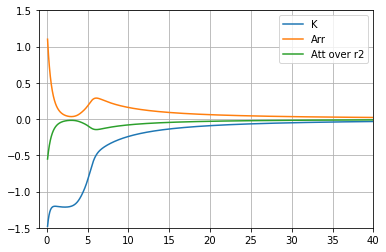

In [356]:
# Check the results
#plt.plot(my_vars.r, my_vars.rho, label='rho')
plt.plot(my_vars.r, my_vars.K, label='K')
#plt.plot(my_vars.r, my_vars.Wr, label='Wr')
plt.plot(my_vars.r, my_vars.Arr * my_vars.psi**(-6.0), label='Arr')
plt.plot(my_vars.r, my_vars.Att * my_vars.psi**(-6.0) / my_vars.r / my_vars.r, label='Att over r2')
#plt.plot(my_vars.r, my_vars.psi, label='psi')
plt.legend()
plt.xlim(-1,40)
plt.ylim(-1.5,1.5)
plt.grid();

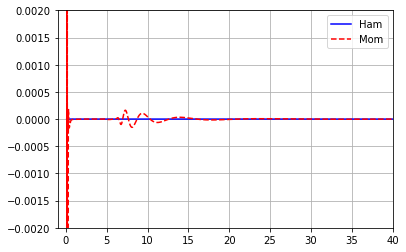

In [357]:
Ham = get_Ham(my_vars)
Mom = get_Mom(my_vars)

plt.plot(my_vars.r, Ham, 'b-', label='Ham')
plt.plot(my_vars.r, Mom, 'r--', label='Mom')
plt.legend()
plt.xlim(-1,40)
plt.ylim(-0.002,0.002)
plt.grid();